# Checking fold results of all methods in summary.json files generated by nnUNet

In [1]:
# imports
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# mixed effects model
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm

In [2]:
# path to predicted data
data_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/iwoai_internal_results/'

# list subfolders at this path
subfolders = [f.name for f in os.scandir(data_path) if f.is_dir()]
print(subfolders)

['nyul_fold_predsTs', 'clip_and_rescale_fold_predsTs', 'rescale_predsTs', 'clahe_predsTs', 'hist_eq_fold_predsTs', 'gmm_predsTs', 'clahe_fold_predsTs', 'nyul_predsTs', 'zscore_hist_match_predsTs', 'gmm_fold_predsTs', 'ResEnc_3d_bs4_predsTs', 'hist_eq_predsTs', 'rescale_fold_predsTs', 'zscore_fold_predsTs', 'ResEnc_32G_3d_predsTs', 'zscore_predsTs', 'clip_rescale_predsTs']


In [3]:
# what metrics are there?
json_path = os.path.join(data_path, 'clahe_fold_predsTs/fold0', 'summary.json')

with open(json_path) as f:
    data = json.load(f)

# extract all metrics
data["metric_per_case"][1]

{'metrics': {'1': {'Dice': 0.9244938864113963,
   'FN': 4706,
   'FP': 6181,
   'Hausdorff_95': 0.8161648511886597,
   'IoU': 0.8595896152804468,
   'TN': 8114463,
   'TP': 66650,
   'n_pred': 72831,
   'n_ref': 71356}},
 'prediction_file': 'clahe_fold_predsTs/fold0/IWOAI_002.nii.gz',
 'reference_file': '../labelsTs/IWOAI_002.nii.gz'}

In [4]:
# functions to take json file and return array of dice scores, or return hausdorff distance
def get_dice_scores(json_file):
    with open(json_file) as f:
        data = json.load(f)

    # Extract Dice scores from "metric_per_case"
    dice_scores = [
        case["metrics"]["1"]["Dice"] for case in data["metric_per_case"]
    ]

    return dice_scores


def get_hausdorff_distances(json_file):
    with open(json_file) as f:
        data = json.load(f)

    # Extract Hausdorff distances from "metric_per_case"
    hausdorff_distances = [
        case["metrics"]["1"]["Hausdorff_95"] for case in data["metric_per_case"]
    ]

    return hausdorff_distances

In [5]:
# get only the subfolders that contain '_fold_'
subfolders = [f for f in subfolders if '_fold_' in f]

subfolders

['nyul_fold_predsTs',
 'clip_and_rescale_fold_predsTs',
 'hist_eq_fold_predsTs',
 'clahe_fold_predsTs',
 'gmm_fold_predsTs',
 'rescale_fold_predsTs',
 'zscore_fold_predsTs']

In [6]:
# reorder the subfolders using the order of the methods (starts with)
method_order = ["zscore", "rescale", "clip_and_rescale", "hist_eq", "clahe", "nyul", "gmm"]

# Sort by checking which method each subfolder starts with
subfolders = sorted(
    subfolders,
    key=lambda x: next((method_order.index(m) for m in method_order if x.lower().startswith(m.lower())), float('inf'))
)
subfolders

['zscore_fold_predsTs',
 'rescale_fold_predsTs',
 'clip_and_rescale_fold_predsTs',
 'hist_eq_fold_predsTs',
 'clahe_fold_predsTs',
 'nyul_fold_predsTs',
 'gmm_fold_predsTs']

In [7]:
# for each folder, go through each fold subfolder (fold0 - fold5) and get average dice scores

# make dictionary to hold the 5 fold averages for each method
fold_averages = {method: [None] * 5 for method in method_order}

for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name
    
    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue
        
        dice_scores = get_dice_scores(json_path)
        fold_averages[method_name][fold] = np.mean(dice_scores)

In [8]:
fold_averages_df = pd.DataFrame(fold_averages)
fold_averages_df.index.name = 'Fold'

# rename columns
fold_averages_df.columns = [
    "Z-score",
    "Min-max",
    "R. Min-max",
    "HE",
    "CLAHE",
    "Nyúl",
    "GMM"
]


In [9]:
fold_averages_df.describe()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,0.890439,0.890504,0.888975,0.886834,0.888300,0.889294,0.890505
std,0.001217,0.000661,0.001439,0.000904,0.000999,0.001869,0.001427
min,0.889442,0.889558,0.887503,0.885358,0.887227,0.886070,0.888874
25%,0.889568,0.890106,0.887744,0.886939,0.887448,0.889575,0.889604
50%,0.889764,0.890709,0.889153,0.886941,0.888177,0.889765,0.890050
75%,0.891224,0.891051,0.889404,0.887097,0.889283,0.890197,0.891923
max,0.892198,0.891096,0.891070,0.887835,0.889365,0.890862,0.892072


In [10]:
# turn dice to percentage
fold_averages_df = fold_averages_df * 100
fold_averages_df.describe()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,89.043945,89.050406,88.897486,88.683407,88.830008,88.929386,89.050452
std,0.121658,0.066050,0.143941,0.090425,0.099893,0.186867,0.142673
min,88.944234,88.955793,88.750330,88.535829,88.722741,88.607030,88.887428
25%,88.956764,89.010633,88.774382,88.693934,88.744842,88.957482,88.960391
50%,88.976438,89.070882,88.915285,88.694088,88.817658,88.976484,89.005013
75%,89.122446,89.105142,88.940407,88.709723,88.928296,89.019711,89.192252
max,89.219843,89.109582,89.107026,88.783458,88.936505,89.086223,89.207177


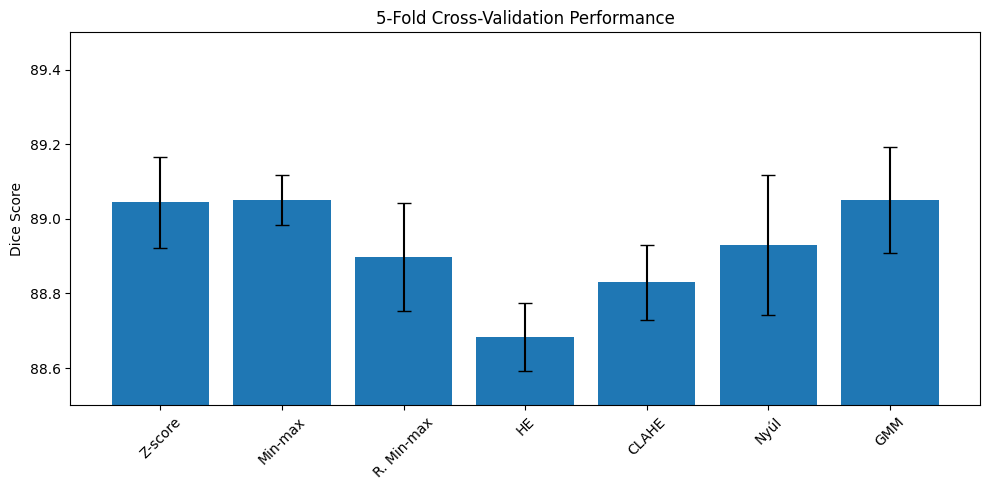

In [11]:
means = fold_averages_df.mean()
stds = fold_averages_df.std()

plt.figure(figsize=(10, 5))
plt.bar(means.index, means.values, yerr=stds.values, capsize=5)
plt.ylabel("Dice Score")
plt.title("5-Fold Cross-Validation Performance")
plt.xticks(rotation=45)
# make y start at 0.8
plt.ylim(88.5, 89.5)
plt.tight_layout()
plt.show()

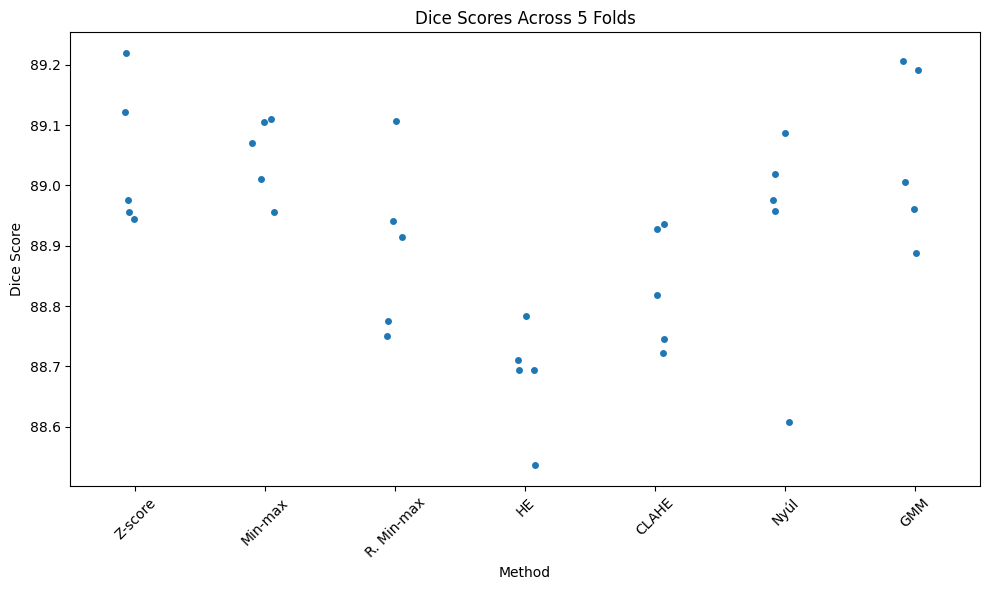

In [12]:
df_long = fold_averages_df.reset_index().melt(id_vars='Fold', var_name='Method', value_name='Dice Score')

plt.figure(figsize=(10, 6))
sns.stripplot(data=df_long, x='Method', y='Dice Score', jitter=True)
plt.title("Dice Scores Across 5 Folds")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

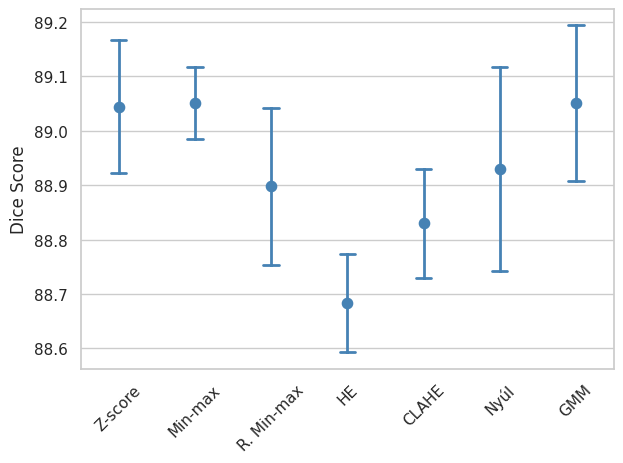

In [13]:
sns.set(style="whitegrid")
sns.pointplot(data=df_long, x='Method', y='Dice Score', errorbar='sd', linestyle='none', markers='o', markersize=5,
    capsize=0.2, linewidth=4.5, color='steelblue', err_kws={'linewidth': 2})
plt.xticks(rotation=45)
# title for fold average distribution across methods
#plt.title("Fold Average Distribution Across Methods")
plt.xlabel(None)
# Tidy layout
plt.tight_layout()
# Save the plot as a PDF
plt.savefig('fold_averages_plot.pdf', bbox_inches='tight', dpi=500, format='pdf')
plt.show()

### Hausdorff 95

In [14]:
# now read the hausdorff distances for each method and fold
hausdorff_averages = {method: [None] * 5 for method in method_order}
for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name

    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue

        hausdorff_distances = get_hausdorff_distances(json_path)
        hausdorff_averages[method_name][fold] = np.mean(hausdorff_distances)

In [15]:
hausdorff_averages_df = pd.DataFrame(hausdorff_averages)
hausdorff_averages_df.index.name = 'Fold'
hausdorff_averages_df.describe()

,zscore,rescale,clip_and_rescale,hist_eq,clahe,nyul,gmm
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,1.506095,1.500088,1.523168,1.544432,1.533290,1.516281,1.483907
std,0.026628,0.027614,0.035320,0.047889,0.030280,0.049496,0.050433
min,1.477365,1.464823,1.465303,1.500211,1.491178,1.484463,1.437551
25%,1.491628,1.488500,1.525827,1.502238,1.512217,1.489972,1.440889
50%,1.500405,1.501878,1.529444,1.536060,1.548249,1.490267,1.466423
75%,1.513595,1.504540,1.533524,1.570909,1.551777,1.514317,1.528392
max,1.547482,1.540699,1.561741,1.612743,1.563031,1.602387,1.546278


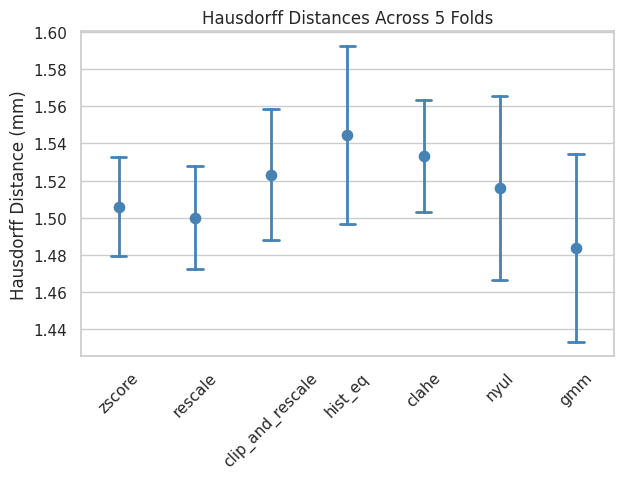

In [16]:
# plot the hausdorff distances
hd_df_long = hausdorff_averages_df.reset_index().melt(id_vars='Fold', var_name='Method', value_name='Hausdorff Distance')
sns.pointplot(data=hd_df_long, x='Method', y='Hausdorff Distance', errorbar='sd', linestyle='none',
    markers='o', markersize=5, capsize=0.2, linewidth=4.5, color='steelblue', err_kws={'linewidth': 2})
plt.xticks(rotation=45)
plt.xlabel(None)
plt.ylabel("Hausdorff Distance (mm)")
plt.tight_layout()
plt.savefig('hausdorff_distances_plot.pdf', bbox_inches='tight', dpi=500, format='pdf')
plt.title("Hausdorff Distances Across 5 Folds")
plt.show()

In [17]:
# Again read in dice scores for each method and fold
# this time storing in long format (method, fold, image_id, dice_score)

data = []

for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name
    
    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue
        
        hd_scores = get_hausdorff_distances(json_path)

        for i, score in enumerate(hd_scores):
            data.append({
                'Method': method_name,
                'Fold': fold,
                'Image_ID': i,
                'HD': score
            })

# Convert to DataFrame
internal_hd_df_long = pd.DataFrame(data)

In [18]:
# save the long format dataframe to a csv file
internal_hd_df_long.to_csv('internal_hd_df_long.csv', index=False)

### Mixed Effects model on internal testing

In [19]:
# Again read in dice scores for each method and fold
# this time storing in long format (method, fold, image_id, dice_score)

data = []

for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name
    
    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue
        
        dice_scores = get_dice_scores(json_path)

        for i, score in enumerate(dice_scores):
            data.append({
                'Method': method_name,
                'Fold': fold,
                'Image_ID': i,
                'Dice_Score': score
            })

# Convert to DataFrame
internal_df_long = pd.DataFrame(data)

In [20]:
internal_df_long.head()

,Method,Fold,Image_ID,Dice_Score
0,zscore,0,0,0.927300
1,zscore,0,1,0.924171
2,zscore,0,2,0.892099
3,zscore,0,3,0.876950
4,zscore,0,4,0.889929


In [21]:
# multiply dice scores by 100 to get percentage
internal_df_long['Dice_Score'] = internal_df_long['Dice_Score'] * 100

In [22]:
# Fit a mixed effects model with a random effects term for fold and Image_ID

internal_df_long["Method"] = pd.Categorical(
    internal_df_long["Method"],
    categories=["zscore", "rescale", "clip_and_rescale", "hist_eq", "clahe", "nyul", "gmm"],
    ordered=True
)

# save the long format DataFrame to a CSV file for R 
internal_df_long.to_csv('internal_df_long.csv', index=False)

# fit mixed effects model with crossed random effects for Image_ID and Fold
internal_df_long['group'] = 1
model = mixedlm(
    "Dice_Score ~ Method",
    internal_df_long,
    groups=internal_df_long["group"],
    re_formula="~1",
    vc_formula={"Image_ID": "0 + C(Image_ID)", "Fold": "0 + C(Fold)"}
)

result = model.fit()
print(result.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       Dice_Score
No. Observations:       980           Method:                   REML      
No. Groups:             1             Scale:                    0.3286    
Min. group size:        980           Log-Likelihood:           -950.5605 
Max. group size:        980           Converged:                Yes       
Mean group size:        980.0                                             
--------------------------------------------------------------------------
                           Coef.    Std.Err.      z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                  89.044        0.785 113.459 0.000 87.506 90.582
Method[T.rescale]           0.006        0.069   0.094 0.925 -0.128  0.141
Method[T.clip_and_rescale] -0.146        0.069  -2.138 0.033 -0.281 -0.012
Method[T.hist_eq]          -0.361        0.0

/users/scojm/.conda/envs/nnunet/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


## External Validation on whole of SKMTEA

In [23]:
data_path = '../nnUNet_data/nnUNet_raw/Dataset361_Menisci/skmtea_external_results/'

# list subfolders at this path
subfolders = [f.name for f in os.scandir(data_path) if f.is_dir()]

# get only the subfolders that contain '_fold_'
subfolders = [f for f in subfolders if '_fold_' in f]

subfolders

['zscore_fold_preds_all_skmtea',
 'nyul_fold_preds_all_skmtea',
 'clahe_fold_preds_all_skmtea',
 'clip_and_rescale_fold_preds_all_skmtea',
 'hist_eq_fold_preds_all_skmtea',
 'rescale_fold_preds_all_skmtea',
 'gmm_fold_preds_all_skmtea']

In [24]:
# reorder the subfolders using the order of the methods (starts with)
method_order = ["zscore", "rescale", "clip_and_rescale", "hist_eq", "clahe", "nyul", "gmm"]
# Sort by checking which method each subfolder starts with
subfolders = sorted(
    subfolders,
    key=lambda x: next((method_order.index(m) for m in method_order if x.lower().startswith(m.lower())), float('inf'))
)
subfolders

['zscore_fold_preds_all_skmtea',
 'rescale_fold_preds_all_skmtea',
 'clip_and_rescale_fold_preds_all_skmtea',
 'hist_eq_fold_preds_all_skmtea',
 'clahe_fold_preds_all_skmtea',
 'nyul_fold_preds_all_skmtea',
 'gmm_fold_preds_all_skmtea']

In [25]:
# for each folder, go through each fold subfolder (fold0 - fold5) and get average dice scores

# make dictionary to hold the 5 fold averages for each method
fold_averages = {method: [None] * 5 for method in method_order}

for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name
    
    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue
        
        dice_scores = get_dice_scores(json_path)
        fold_averages[method_name][fold] = np.mean(dice_scores)

In [26]:
fold_averages_df.head()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
Fold,,,,,,,
0,88.944234,89.105142,88.940407,88.693934,88.936505,88.957482,89.207177
1,88.976438,89.070882,88.915285,88.709723,88.744842,89.086223,88.960391
2,89.219843,89.109582,89.107026,88.783458,88.928296,89.019711,89.192252
3,89.122446,88.955793,88.750330,88.535829,88.817658,88.976484,88.887428
4,88.956764,89.010633,88.774382,88.694088,88.722741,88.607030,89.005013


In [27]:
external_fold_averages_df = pd.DataFrame(fold_averages)
external_fold_averages_df = external_fold_averages_df * 100  # convert to percentage
external_fold_averages_df.index.name = 'Fold'

# rename columns
external_fold_averages_df.columns = [
    "Z-score",
    "Min-max",
    "R. Min-max",
    "HE",
    "CLAHE",
    "Nyúl",
    "GMM"
]

external_fold_averages_df.describe()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,78.951923,78.445944,78.475143,78.306698,78.859902,79.095101,78.438879
std,0.284022,0.227903,0.255027,0.237155,0.259435,0.336691,0.140816
min,78.462321,78.113409,78.175414,78.037883,78.407721,78.552915,78.203241
25%,78.942994,78.384569,78.256591,78.245229,78.903122,79.089085,78.411963
50%,79.114149,78.417777,78.529595,78.250683,78.928202,79.092377,78.521113
75%,79.117187,78.614873,78.629539,78.311195,79.020258,79.308622,78.524187
max,79.122966,78.699089,78.784577,78.688501,79.040210,79.432508,78.533889


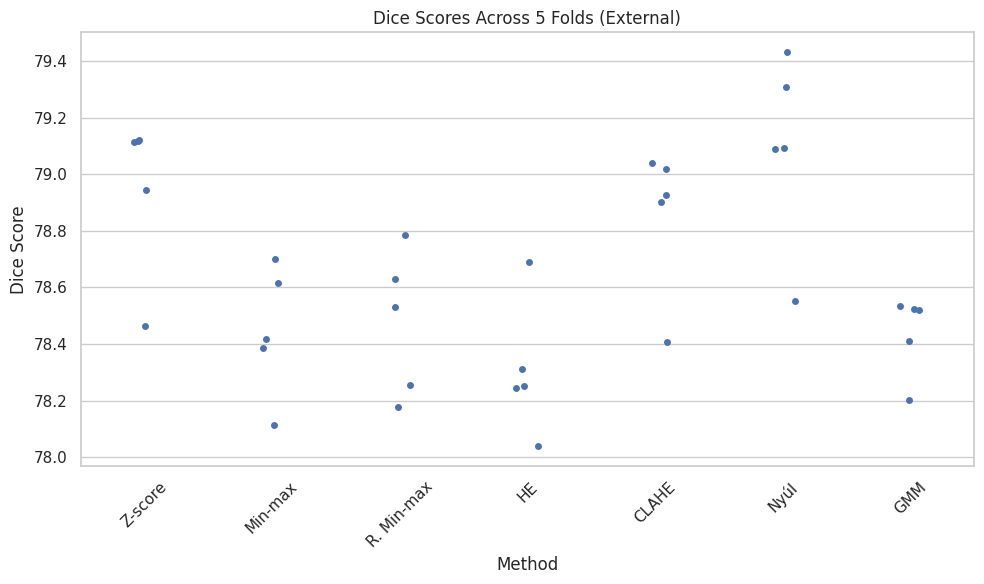

In [28]:
ext_df_long = external_fold_averages_df.reset_index().melt(id_vars='Fold', var_name='Method', value_name='Dice Score')
plt.figure(figsize=(10, 6))
sns.stripplot(data=ext_df_long, x='Method', y='Dice Score', jitter=True)
plt.title("Dice Scores Across 5 Folds (External)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

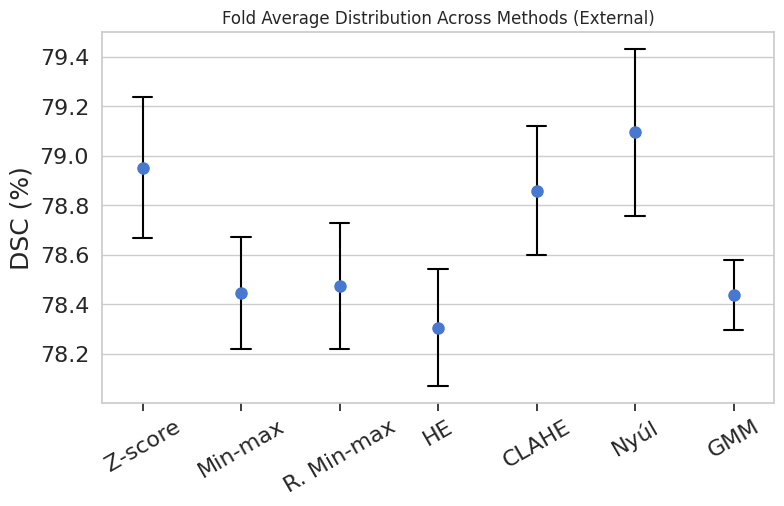

In [29]:
plt.figure(figsize=(8, 5))
sns.set_style("whitegrid", {'xtick.bottom': True})
ax = sns.pointplot(data=ext_df_long, x='Method', y='Dice Score', errorbar='sd', linestyle='none',
    markers='o', markersize=6, capsize=0.2, color=sns.color_palette("muted")[0], err_kws={'linewidth': 1.5, 'color': 'black'})

# Redraw the markers on top
for line in ax.lines:
    ax.plot(line.get_xdata(), line.get_ydata(), 'o', color=line.get_color(), zorder=3, markersize=8)
    break

plt.xticks(rotation=30, fontsize=16)
plt.yticks(fontsize=16)
plt.xlabel(None)
plt.ylabel("DSC (%)", fontsize=18)
plt.tight_layout()
# Save the plot as a PDF
#plt.savefig('external_fold_averages_plot.pdf', bbox_inches='tight', dpi=500, format='pdf')
plt.title("Fold Average Distribution Across Methods (External)")
plt.show()

In [30]:
fold_averages_df

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
Fold,,,,,,,
0,88.944234,89.105142,88.940407,88.693934,88.936505,88.957482,89.207177
1,88.976438,89.070882,88.915285,88.709723,88.744842,89.086223,88.960391
2,89.219843,89.109582,89.107026,88.783458,88.928296,89.019711,89.192252
3,89.122446,88.955793,88.750330,88.535829,88.817658,88.976484,88.887428
4,88.956764,89.010633,88.774382,88.694088,88.722741,88.607030,89.005013


In [31]:
fold_averages_ext_int_diff = external_fold_averages_df - fold_averages_df
fold_averages_ext_int_diff.describe()

,Z-score,Min-max,R. Min-max,HE,CLAHE,Nyúl,GMM
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,-10.092021,-10.604463,-10.422343,-10.376708,-9.970106,-9.834285,-10.611573
std,0.241411,0.227134,0.198635,0.208344,0.236734,0.202296,0.202141
min,-10.494442,-10.897223,-10.598968,-10.656205,-10.315020,-10.054115,-10.801772
25%,-10.105695,-10.687365,-10.577431,-10.464494,-10.033383,-9.993846,-10.795214
50%,-10.001240,-10.686313,-10.493738,-10.382739,-10.000094,-9.868397,-10.658363
75%,-9.999480,-10.410493,-10.310869,-10.285146,-9.797400,-9.667862,-10.439277
max,-9.859251,-10.340920,-10.130708,-10.094958,-9.704632,-9.587203,-10.363241


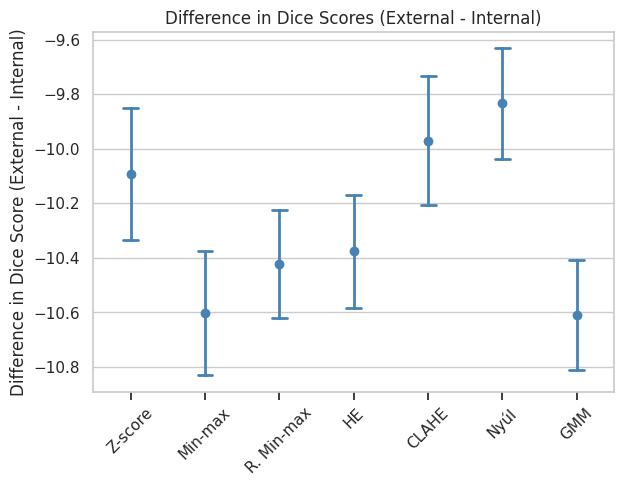

In [32]:
# plot the differences
sns.pointplot(data=fold_averages_ext_int_diff.reset_index().melt(id_vars='Fold', var_name='Method', value_name='Difference'),
                x='Method', y='Difference', errorbar='sd', linestyle='none', markers='o', markersize=5,
                capsize=0.2, color='steelblue', err_kws={'linewidth': 2})
plt.xticks(rotation=45)
plt.xlabel(None)
plt.ylabel("Difference in Dice Score (External - Internal)")
plt.tight_layout()
plt.savefig('fold_averages_ext_int_diff_plot.pdf', bbox_inches='tight', dpi=500, format='pdf')
plt.title("Difference in Dice Scores (External - Internal)")
plt.show()

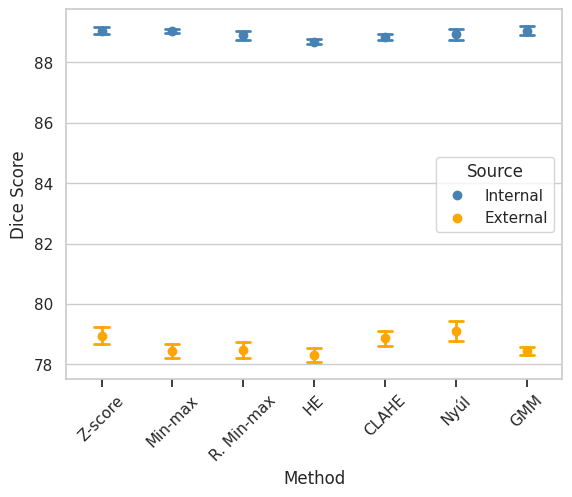

In [33]:
# plot both on same plot
combined_df = pd.concat([df_long.assign(Source='Internal'), ext_df_long.assign(Source='External')])

sns.pointplot(data=combined_df, x='Method', y='Dice Score', hue='Source', errorbar='sd',
                linestyle='none', markers='o', markersize=5, capsize=0.2,
                err_kws={'linewidth': 2}, palette=['steelblue', 'orange'])
plt.xticks(rotation=45)
plt.show()

### external hausdorff

In [34]:
# plot hausdorff distances for external results
hausdorff_averages = {method: [None] * 5 for method in method_order}
for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name

    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue

        hausdorff_distances = get_hausdorff_distances(json_path)
        hausdorff_averages[method_name][fold] = np.mean(hausdorff_distances)

In [35]:
hausdorff_averages_df = pd.DataFrame(hausdorff_averages)
hausdorff_averages_df.index.name = 'Fold'
hausdorff_averages_df.describe()

,zscore,rescale,clip_and_rescale,hist_eq,clahe,nyul,gmm
count,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000
mean,3.192129,3.207918,3.090530,3.295861,3.051003,3.189277,3.169973
std,0.205016,0.127895,0.111982,0.149179,0.234445,0.237675,0.067819
min,2.983248,3.048491,2.977984,3.080249,2.896117,2.871673,3.055192
25%,2.997755,3.091452,3.041058,3.232165,2.939744,3.071266,3.164142
50%,3.180912,3.273414,3.066783,3.301994,2.949243,3.156320,3.197198
75%,3.380758,3.309645,3.090604,3.408770,3.005329,3.411472,3.210063
max,3.417975,3.316589,3.276223,3.456130,3.464583,3.435654,3.223269


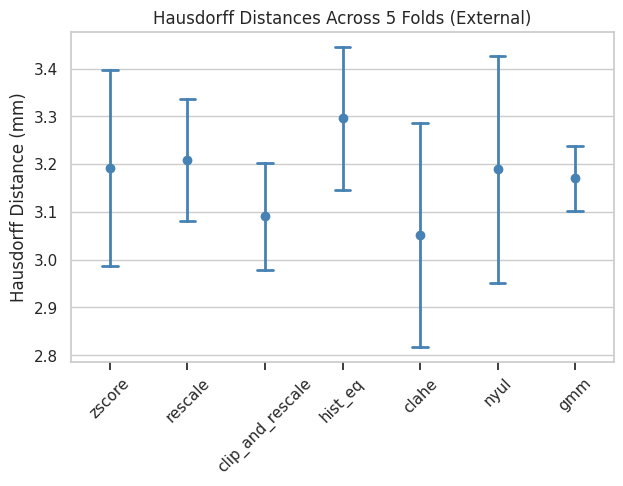

In [36]:
# plot hausdorff distances as sns pointplot
hd_df_long = hausdorff_averages_df.reset_index().melt(id_vars='Fold', var_name='Method', value_name='Hausdorff Distance')
sns.pointplot(data=hd_df_long, x='Method', y='Hausdorff Distance', errorbar='sd', linestyle='none',
    markers='o', markersize=5, capsize=0.2, color='steelblue', err_kws={'linewidth': 2})
plt.xticks(rotation=45)
plt.xlabel(None)
plt.ylabel("Hausdorff Distance (mm)")
plt.tight_layout()
plt.savefig('external_hausdorff_distances_plot.pdf', bbox_inches='tight', dpi=500, format='pdf')
plt.title("Hausdorff Distances Across 5 Folds (External)")
plt.show()

In [37]:
# Again read in dice scores for each method and fold
# this time storing in long format (method, fold, image_id, dice_score)

data = []

for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name
    
    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue
        
        hd_scores = get_hausdorff_distances(json_path)

        for i, score in enumerate(hd_scores):
            data.append({
                'Method': method_name,
                'Fold': fold,
                'Image_ID': i,
                'HD': score
            })

# Convert to DataFrame
external_hd_df_long = pd.DataFrame(data)

In [38]:
# save hd_df_long to csv
external_hd_df_long.to_csv('external_hd_df_long.csv', index=False)

# Attempt at Mixed Effects Model for external results

In [39]:
# Again read in dice scores for each method and fold
# this time storing in long format (method, fold, image_id, dice_score)

data = []

for folder in subfolders:
    method_name = folder.split('_fold_')[0]  # Extract method name from folder name
    
    # go through all 5 folds
    for fold in range(5):
        json_path = os.path.join(data_path, folder, f'fold{fold}', 'summary.json')
        if not os.path.exists(json_path):
            print(f"Warning: {json_path} does not exist.")
            continue
        
        dice_scores = get_dice_scores(json_path)

        for i, score in enumerate(dice_scores):
            data.append({
                'Method': method_name,
                'Fold': fold,
                'Image_ID': i,
                'Dice_Score': score
            })

# Convert to DataFrame
external_df_long = pd.DataFrame(data)

In [40]:
external_df_long.head()

,Method,Fold,Image_ID,Dice_Score
0,zscore,0,0,0.809381
1,zscore,0,1,0.801625
2,zscore,0,2,0.821544
3,zscore,0,3,0.799143
4,zscore,0,4,0.816070


In [41]:
# turn dice scores into percentage
external_df_long['Dice_Score'] = external_df_long['Dice_Score'] * 100

In [42]:
# save the long format DataFrame to a CSV file for R
external_df_long.to_csv('external_df_long.csv', index=False)

In [43]:
# fit mixed effects model with crossed random effects for Image_ID and Fold
external_df_long["Method"] = pd.Categorical(
    external_df_long["Method"],
    categories=["zscore", "rescale", "clip_and_rescale", "hist_eq", "clahe", "nyul", "gmm"],
    ordered=True
)

# add a group column for the mixed effects model
external_df_long['group'] = 1

model = mixedlm(
    "Dice_Score ~ Method", 
    external_df_long,
    groups=external_df_long["group"],
    re_formula="~1",
    vc_formula={"Image_ID": "0 + C(Image_ID)", "Fold": "0 + C(Fold)"}
)

result = model.fit()
print(result.summary())

# save result.summary table as a pdf

                  Mixed Linear Model Regression Results
Model:                  MixedLM       Dependent Variable:       Dice_Score
No. Observations:       5425          Method:                   REML      
No. Groups:             1             Scale:                    0.9278    
Min. group size:        5425          Log-Likelihood:           -8012.1388
Max. group size:        5425          Converged:                Yes       
Mean group size:        5425.0                                            
--------------------------------------------------------------------------
                           Coef.    Std.Err.      z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                  78.952        1.026  76.955 0.000 76.941 80.963
Method[T.rescale]          -0.506        0.049 -10.341 0.000 -0.602 -0.410
Method[T.clip_and_rescale] -0.477        0.049  -9.744 0.000 -0.573 -0.381
Method[T.hist_eq]          -0.645        0.0

In [49]:
external_df_long[external_df_long['Image_ID'] == 77]

,Method,Fold,Image_ID,Dice_Score,group
77,zscore,0,77,75.365400,1
232,zscore,1,77,80.582996,1
387,zscore,2,77,80.867233,1
542,zscore,3,77,82.088783,1
697,zscore,4,77,79.031041,1
852,rescale,0,77,74.264915,1
1007,rescale,1,77,73.582246,1
1162,rescale,2,77,77.243464,1
1317,rescale,3,77,73.642787,1
1472,rescale,4,77,71.918828,1


In [47]:
# Look for image that deviates the most across methods in dice scores
external_df_long.groupby('Image_ID')['Dice_Score'].std().sort_values(ascending=False).head()

Image_ID
77     4.343070
53     4.009554
111    3.538855
87     3.092225
52     2.885580
Name: Dice_Score, dtype: float64

In [51]:
# collapse all fold results for each image and method into a single average dice score per image and method
external_df_image_method_avg = external_df_long.groupby(['Image_ID', 'Method'])['Dice_Score'].mean().reset_index()
external_df_image_method_avg.head(10)

/tmp/ipykernel_3108514/2859166908.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  external_df_image_method_avg = external_df_long.groupby(['Image_ID', 'Method'])['Dice_Score'].mean().reset_index()


,Image_ID,Method,Dice_Score
0,0,zscore,80.248893
1,0,rescale,79.823174
2,0,clip_and_rescale,80.130773
3,0,hist_eq,80.076824
4,0,clahe,80.372220
5,0,nyul,80.102748
6,0,gmm,79.869001
7,1,zscore,80.423627
8,1,rescale,80.423491
9,1,clip_and_rescale,80.356107


In [54]:
# Look for image that deviates the most across methods in dice scores
external_df_image_method_avg.groupby('Image_ID')['Dice_Score'].std().sort_values(ascending=False).head()

Image_ID
77     4.417365
53     4.095037
127    2.486988
111    2.446062
87     1.967446
Name: Dice_Score, dtype: float64